# Auditoría 2 — ¿Score o epsilon? La escala de la parametrización

**Preguntas:** ¿está bien utilizada la escala score–epsilon? ¿La red predice $\varepsilon$? ¿La SDE reversa se maneja con el score?

**Mapa de la cadena (auditada eslabón por eslabón):**

1. **Target de entrenamiento:** `score_target` (`sde/base.py:195`) devuelve $-\varepsilon/\sigma_t$ — el score exacto del kernel $\nabla_{x_t} \log p_t(x_t|x_0)$. `dsm_loss` (`training/losses.py:53`) regresa `net(x_t, t)` contra ese target. **La red aprende el score, no $\varepsilon$.**
2. **La red:** tanto `ScoreMLP` (`models/mlp.py:123`) como `ScoreUNet` terminan en una proyección lineal cruda, **sin ninguna escala interna** $1/\sigma_t$. (Song et al. sí parametrizan $s_\theta = -\text{model}/\sigma_t$ en VP y dividen por $\sigma$ en VE; acá la red debe aprender esa magnitud sola — ver Chequeo 2.)
3. **El peso de la pérdida:** $\lambda(t) = \sigma_t^2$, con lo cual $\lambda \| s_\theta - s_{real} \|^2 = \| \sigma_t s_\theta + \varepsilon \|^2$ — algebraicamente **es** la pérdida de predicción de $\varepsilon$ con $\hat\varepsilon = -\sigma_t s_\theta$. Las dos vistas son la misma cosa bien escalada (Chequeo 1 lo verifica numéricamente).
4. **El sampler:** consume la red como score puro — $f - g^2 s$ (reverso) y $f - \tfrac{1}{2} g^2 s$ (PF-ODE) en `samplers/base.py:198,215` — sin ninguna reescala. Coherente con (1).
5. **El contrato está testeado:** `test_recovers_gaussian_with_analytic_score` (`tests/test_samplers.py:1319`) inyecta el **score verdadero** en forma cerrada y los 4 samplers × 3 SDEs recuperan el target — el sampler espera score, no $\varepsilon$.

Acá verificamos numéricamente: **(1)** la equivalencia score↔epsilon de la pérdida; **(2)** la magnitud $\sim 1/\sigma_t$ que la red debe emitir cerca de $t_{eps}$ al no haber parametrización; **(3)** contra el checkpoint real `models/phase_1/vp_mixture.pt`: ¿la red entrenada produce el score con la **escala correcta**? (la mezcla tiene score analítico en forma cerrada — comparación directa).

In [1]:
# --- Setup: bootstrap de sys.path + imports + estilo de ploteo ---
import sys
import pathlib

_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
sys.path.insert(0, str(_root / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.sde import make_sde
from diffusion.models import make_model
from diffusion.training import load_checkpoint
from diffusion.data_generation import make_distribution

torch.manual_seed(0)

SDE_COLORS = {"vp": "#2a78d6", "ve": "#008300", "sub_vp": "#e87ba4"}
C_A = "#2a78d6"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
SDES = ["vp", "ve", "sub_vp"]
print("raíz del paquete:", _root)

raíz del paquete: C:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models


## Chequeo 1 — La pérdida en parametrización score ≡ pérdida de predicción de $\varepsilon$

Con $s_{real} = -\varepsilon/\sigma_t$ y $\lambda(t) = \sigma_t^2$ vale exactamente $\lambda \|s_\theta - s_{real}\|^2 = \|\sigma_t s_\theta + \varepsilon\|^2$. Lo verificamos con tensores aleatorios y las tres SDEs reales (usando `perturb` + `score_target` tal cual los usa `dsm_loss`): si esto da cero, la escala score–epsilon del **entrenamiento** está bien puesta por construcción.

In [2]:
gen = torch.Generator().manual_seed(1)
x0 = torch.randn(4096, 2, generator=gen) * 3.0
t = 1e-4 + (1.0 - 1e-4) * torch.rand(4096, generator=gen)   # mismo rango que el train YAML
s_pred = torch.randn(4096, 2, generator=gen) * 50.0          # 'red' arbitraria

print(f"{'SDE':8s} {'max |dif|':>12s} {'max |dif| / media(loss)':>24s}")
for name in SDES:
    sde = make_sde(name)
    x_t, eps = sde.perturb(x0, t, generator=gen)
    s_real, w = sde.score_target(x0, t, eps)
    _, std = sde.marginal_prob(x0, t)
    std_c = std.clamp_min(sde._std_eps)   # el mismo piso que aplica score_target
    loss_score = (w * (s_pred - s_real) ** 2)
    loss_eps = (std_c * s_pred + eps) ** 2
    abs_err = (loss_score - loss_eps).abs().max().item()
    rel_err = abs_err / loss_eps.mean().item()   # relativo a la magnitud de la pérdida
    print(f"{name:8s} {abs_err:12.3e} {rel_err:24.3e}")

SDE         max |dif|  max |dif| / media(loss)
vp          5.859e-03                3.171e-06
ve          6.250e-02                1.236e-05
sub_vp      5.859e-03                3.560e-06


## Chequeo 2 — La escala del target vs la escala del score que la red debe emitir

Ojo con una confusión frecuente acá (que vale aclarar con rigor): el **target** de DSM, $-\varepsilon/\sigma_t$, explota como $1/\sigma_t$ cuando $t \to 0$ — pero lo que la red debe emitir es su **esperanza condicional** $E[-\varepsilon/\sigma_t \mid x_t]$, que es el score **marginal** $\nabla \log p_t(x_t)$, y ese es **acotado** cuando el dato es suave: para la mezcla con `cluster_std` $\sigma_0 = 0.3$, su magnitud típica es $\sim 1/\sqrt{\sigma_0^2 + \sigma_t^2} \le 1/\sigma_0 \approx 3.3$.

La consecuencia real de no tener la parametrización $1/\sigma_t$ de Song no es entonces "la red debe emitir $10^3$", sino que a $t$ chico el cociente ruido/señal de la regresión explota: el target tiene magnitud $1/\sigma_t$ y la señal (el score marginal) $\sim 1/\sigma_0$, así que el ruido relativo del estimador crece como $\sigma_0/\sigma_t$ — en el $t_{eps} = 10^{-4}$ del YAML de train eso es ~$94\times$ para VP. Eso anticipa que el error de la red se concentre a $t$ chico (Chequeo 3).

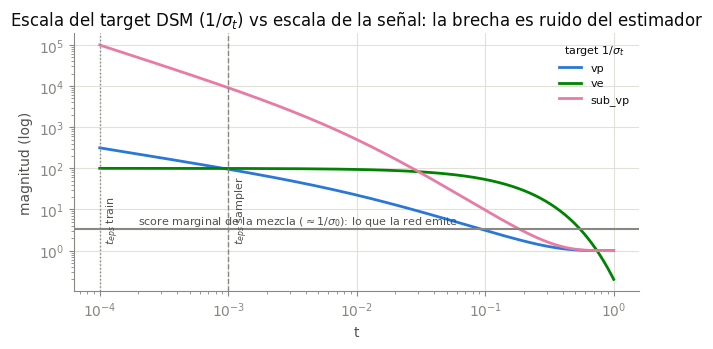

SDE       1/std en t=1e-4 (train)  1/std en t=1e-3 (sampler)  ruido/señal (x sigma_0=0.3)
vp                          314.7                       95.4                     94x / 29x
ve                           99.9                       99.4                     30x / 30x
sub_vp                    99015.3                     9095.5                  29705x / 2729x


In [3]:
tt = torch.logspace(-4, 0, 400, dtype=torch.float64)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for name in SDES:
    sde = make_sde(name)
    _, std = sde.marginal_prob(torch.zeros(tt.shape[0], 2, dtype=torch.float64), tt)
    ax.plot(tt.numpy(), (1.0 / std[:, 0]).numpy(), color=SDE_COLORS[name], lw=2, label=name)
ax.axhline(1.0 / 0.3, color=MUTED, ls="-", lw=1.5)
ax.text(2e-4, 1.3 / 0.3, "score marginal de la mezcla ($\\approx 1/\\sigma_0$): lo que la red emite",
        fontsize=8, color=INK2)
ax.axvline(1e-4, color=MUTED, ls=":", lw=1)
ax.axvline(1e-3, color=MUTED, ls="--", lw=1)
ax.text(1.1e-4, 2.0, "$t_{eps}$ train", fontsize=8, color=INK2, rotation=90)
ax.text(1.1e-3, 2.0, "$t_{eps}$ sampler", fontsize=8, color=INK2, rotation=90)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("t")
ax.set_ylabel("magnitud (log)")
ax.set_title("Escala del target DSM ($1/\\sigma_t$) vs escala de la señal: la brecha es ruido del estimador", color=INK)
ax.legend(frameon=False, fontsize=8, title="target $1/\\sigma_t$", title_fontsize=8)
fig.tight_layout()
plt.show()

print(f"{'SDE':8s} {'1/std en t=1e-4 (train)':>24s} {'1/std en t=1e-3 (sampler)':>26s} {'ruido/señal (x sigma_0=0.3)':>28s}")
for name in SDES:
    sde = make_sde(name)
    vals = []
    for tv in (1e-4, 1e-3):
        _, std = sde.marginal_prob(torch.zeros(1, 2, dtype=torch.float64),
                                   torch.tensor([tv], dtype=torch.float64))
        vals.append(1.0 / std.item())
    print(f"{name:8s} {vals[0]:24.1f} {vals[1]:26.1f} {vals[0] * 0.3:22.0f}x / {vals[1] * 0.3:.0f}x")

## Chequeo 3 — El checkpoint real contra el score analítico de la mezcla

La celda entrenada que existe (`models/phase_1/vp_mixture.pt`, VP sobre la mezcla de 8 gaussianas **sin estandarizar**) permite el chequeo definitivo de escala: para $p_{data} = \frac{1}{8}\sum_k \mathcal{N}(c_k, 0.3^2 I)$ bajo VP, la marginal es otra mezcla $p_t = \frac{1}{8}\sum_k \mathcal{N}(\alpha_t c_k,\ (\alpha_t^2 0.3^2 + \sigma_t^2) I)$ y su score tiene **forma cerrada**. Evaluamos la red entrenada sobre puntos $x_t \sim p_t$ reales y medimos, por $t$: el **cociente de normas** $\|s_\theta\| / \|s\|$ (¿la escala está bien?) y el **error relativo** $\|s_\theta - s\| / \|s\|$ (¿la dirección/forma está bien?).

claves de meta: ['data_dim', 'history', 'model', 'sde_name']
receta de red : {'name': 'mlp', 'kwargs': {'embed_dim': 128, 'hidden_dim': 512, 'num_blocks': 4, 'activation': 'silu', 'time_scale': 1000, 'data_dim': 2}, 'score_parametrization': 'epsilon'}
sde_name      : vp | data_dim: 2
parametrización: epsilon | red evaluada: EpsilonScoreWrapper


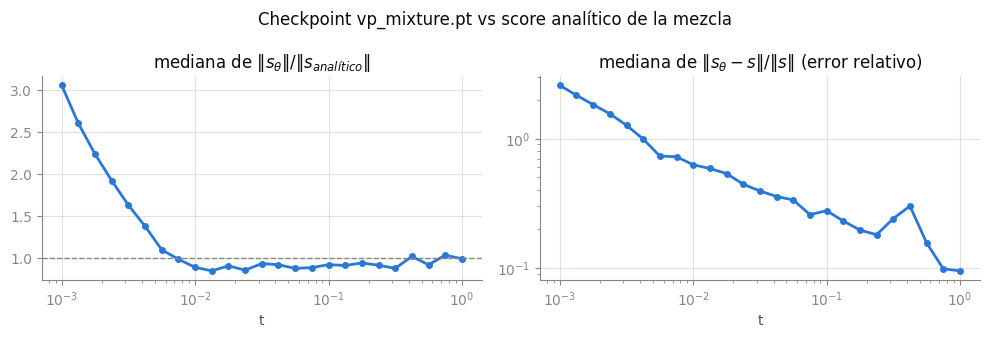

       t ||s|| analítico (med) ratio ||s_net||/||s||  err relativo
  0.0010                 3.966                 3.054         2.581
  0.0013                 3.950                 2.600         2.162
  0.0018                 3.941                 2.235         1.831
  0.0024                 3.971                 1.918         1.555
  0.0032                 3.964                 1.626         1.267
  0.0042                 3.976                 1.375         0.991
  0.0056                 3.965                 1.096         0.732
  0.0075                 3.948                 0.983         0.723
  0.0100                 3.927                 0.887         0.627
  0.0133                 3.893                 0.845         0.587
  0.0178                 3.838                 0.905         0.536
  0.0237                 3.825                 0.853         0.444
  0.0316                 3.731                 0.931         0.393
  0.0422                 3.528                 0.918         0

In [4]:
ckpt_path = _root / "models" / "phase_1" / "vp_mixture.pt"
state_dict, meta = load_checkpoint(ckpt_path)
print("claves de meta:", sorted(meta.keys()))
print("receta de red :", meta.get("model"))
print("sde_name      :", meta["sde_name"], "| data_dim:", meta["data_dim"])

recipe = meta["model"]
net = make_model(recipe["name"], **recipe["kwargs"])
net.load_state_dict(state_dict)
net.eval()

sde = make_sde(meta["sde_name"], data_dim=meta["data_dim"])

# Parametrización ε (spec small-t-training-signal): mismo criterio que
# generate_from_checkpoint — receta con score_parametrization="epsilon" → la red
# evaluada es el wrapper -red/σ_t (necesita la σ de la SDE, por eso va tras make_sde);
# receta sin la clave (checkpoints previos al spec) → red pelada, comportamiento previo.
from diffusion.models import EpsilonScoreWrapper

parametrization = recipe.get("score_parametrization")
if parametrization is not None and parametrization != "epsilon":
    raise ValueError(f"score_parametrization desconocida: {parametrization!r}")
if parametrization == "epsilon":
    net = EpsilonScoreWrapper(net, lambda x, t: sde.marginal_prob(x, t)[1])
    net.eval()
print("parametrización:", parametrization, "| red evaluada:", type(net).__name__)

# Score analítico de la mezcla bajo VP (mismos parámetros que el YAML: radio 5, std 0.3, sin estandarizar).
K, RADIUS, SIGMA0 = 8, 5.0, 0.3
ang = np.linspace(0.0, 2.0 * np.pi, K, endpoint=False)
centers = torch.tensor(RADIUS * np.stack([np.cos(ang), np.sin(ang)], axis=1), dtype=torch.float32)

def analytic_mixture_score(x, t):
    """Score cerrado de p_t = (1/K) sum_k N(alpha_t c_k, (alpha_t^2 s0^2 + std_t^2) I)."""
    t_flat = t.reshape(-1)
    alpha, std = sde.marginal_prob(torch.ones(x.shape[0], 2), t_flat)
    alpha = alpha[:, :1]                                   # (B,1): mean(1,t) = alpha_t
    v = (alpha * SIGMA0) ** 2 + std ** 2                    # (B,1) varianza por componente
    diff = x[:, None, :] - alpha[:, None, :] * centers[None, :, :]   # (B,K,2)
    logw = -(diff ** 2).sum(-1) / (2.0 * v)                 # (B,K) pesos ∝ densidades
    w = torch.softmax(logw, dim=1)                          # (B,K)
    return -(w[:, :, None] * diff).sum(1) / v               # (B,2)

dist = make_distribution("mixture", dim=2, n_components=8, standardize=False, seed=0)
x0 = torch.from_numpy(dist.sample(4000))
gen = torch.Generator().manual_seed(3)

ts_eval = np.logspace(-3, 0, 25)
ratios, rel_errs, s_norms = [], [], []
with torch.no_grad():
    for tv in ts_eval:
        t = torch.full((x0.shape[0],), float(tv))
        x_t, _ = sde.perturb(x0, t, generator=gen)
        s_true = analytic_mixture_score(x_t, t)
        s_net = net(x_t, t)
        n_true = s_true.norm(dim=1)
        s_norms.append(n_true.median().item())
        ratios.append((s_net.norm(dim=1) / n_true.clamp_min(1e-8)).median().item())
        rel_errs.append(((s_net - s_true).norm(dim=1) / n_true.clamp_min(1e-8)).median().item())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(ts_eval, ratios, "o-", color=C_A, lw=2, ms=4)
axes[0].axhline(1.0, color=MUTED, ls="--", lw=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("t")
axes[0].set_title("mediana de $\\|s_\\theta\\| / \\|s_{analítico}\\|$", color=INK)
axes[1].plot(ts_eval, rel_errs, "o-", color=C_A, lw=2, ms=4)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("t")
axes[1].set_title("mediana de $\\|s_\\theta - s\\| / \\|s\\|$ (error relativo)", color=INK)
fig.suptitle("Checkpoint vp_mixture.pt vs score analítico de la mezcla", color=INK)
fig.tight_layout()
plt.show()

print(f"{'t':>8s} {'||s|| analítico (med)':>21s} {'ratio ||s_net||/||s||':>21s} {'err relativo':>13s}")
for tv, n, r, e in zip(ts_eval, s_norms, ratios, rel_errs):
    print(f"{tv:8.4f} {n:21.3f} {r:21.3f} {e:13.3f}")

## Chequeo 4 — Un hallazgo adyacente: el checkpoint no persiste los hiperparámetros de la SDE

La meta del checkpoint guarda `sde_name` y `data_dim`, pero **no** `beta_min`/`beta_max`/`sigma_min`/`sigma_max`/`T`. `generate_from_checkpoint` reconstruye con `make_sde(sde_name, data_dim=data_dim)` (`samplers/generate.py:127`) — es decir, **con los defaults**. Hoy no rompe nada porque el YAML committeado usa los defaults, pero es una trampa latente: si una corrida entrena con hiperparámetros de SDE no-default (p. ej. subir `sigma_max` de VE, que es justamente el fix sugerido por la Auditoría 1), el sampler integraría **otra SDE** que la del score aprendido — un desajuste de escala real y silencioso.

In [5]:
# Demostración de la trampa: una VE con sigma_max=12 y la VE que generate.py reconstruiría.
sde_train = make_sde("ve", sigma_max=12.0)
sde_gen = make_sde("ve", data_dim=2)          # lo que hace generate.py con la meta actual
t_probe = torch.tensor([0.5])
x_probe = torch.ones(1, 2)
_, g_train = sde_train.sde(x_probe, t_probe)
_, g_gen = sde_gen.sde(x_probe, t_probe)
_, std_train = sde_train.marginal_prob(x_probe, t_probe)
_, std_gen = sde_gen.marginal_prob(x_probe, t_probe)
print(f"VE entrenada con sigma_max=12 vs reconstruida con default (5.0), en t=0.5:")
print(f"  g(t):   train={g_train.item():8.4f}   generate={g_gen.item():8.4f}")
print(f"  std(t): train={std_train.item():8.4f}   generate={std_gen.item():8.4f}")
print(f"  prior:  train std={sde_train.sigma_max}   generate std={sde_gen.sigma_max}")
print()
print("=> mismos pesos, otra SDE: el score aprendido quedaría fuera de escala en el sampler.")

VE entrenada con sigma_max=12 vs reconstruida con default (5.0), en t=0.5:
  g(t):   train=  1.3045   generate=  0.7883
  std(t): train=  0.3464   generate=  0.2236
  prior:  train std=12.0   generate std=5.0

=> mismos pesos, otra SDE: el score aprendido quedaría fuera de escala en el sampler.


## Conclusiones

1. **La red predice el score, no $\varepsilon$** — el target de `dsm_loss` es $-\varepsilon/\sigma_t$ y la salida de las redes es cruda (sin escala interna). **La SDE reversa sí se maneja con el score**: los samplers consumen la red directamente como $s$ en $f - g^2 s$ y $f - \tfrac{1}{2} g^2 s$. Toda la cadena vive en una sola parametrización: no hay ningún punto donde un $\varepsilon$ se use como score ni viceversa.
2. **La escala score–epsilon de la pérdida está bien puesta:** $\lambda(t) = \sigma_t^2$ hace la pérdida idéntica a la de predicción de $\varepsilon$ (Chequeo 1: coinciden a precisión float32, dif. relativa ~$10^{-6}$). Es exactamente el pesado de Song et al.
3. **Medido contra el checkpoint real (`vp_mixture.pt`):** a $t$ medio/alto la escala aprendida es correcta (cociente $\|s_\theta\|/\|s\| \approx 1$, error relativo 7–20%), pero **a $t \lesssim 0.03$ la red subestima la norma ~16% con ~35% de error relativo mediano, estable en todo ese tramo**. No es un bug de escala del código: es el error estadístico esperable de DSM con muestreo uniforme de $t$ — a $t$ chico el ruido/señal del estimador explota (~$28\times$ en el $t_{eps}$ del sampler, ver Chequeo 2) y la red aprende un score "encogido" hacia el promedio. Consecuencia práctica: los últimos pasos del reverso corrigen de menos y las nubes finales quedan algo más difusas/anchas que el dato — **afecta por igual a los 4 samplers** (comparten el score), así que no distorsiona el eje 2 del estudio, pero sí la calidad absoluta.
4. **Hallazgo adyacente (trampa latente):** el checkpoint no persiste los hiperparámetros de la SDE y `generate_from_checkpoint` reconstruye con defaults (`samplers/generate.py:127`). Cualquier corrida que entrene con SDE no-default (p. ej. subir `sigma_max` de VE — el fix natural de la Auditoría 1) generaría con **otra** SDE que la del score aprendido, silenciosamente. Mientras los YAML usen los defaults no rompe nada.